# Computational Social Science Project #3 

**Enter your Name:** Yidan Tang

*Semester:* Fall 2025

## 1. Introduction

### Load data 

In [21]:
#
# load libraries
# -----------
import pandas as pd
import numpy as np
pd.set_option('display.max_columns', None)
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
from sklearn.preprocessing import LabelBinarizer

# There are a few warnings that will appear that will not affect your analysis. Run this code to ignore. 
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

# Make sure to import other libraries that will be necessary for training models!

In [22]:
#
# read in "Inspections Data 2011-2013" csv data
# -----------
chicago_inspections_2011_to_2013 = pd.read_csv("data/Chicago Inspections 2011-2013.csv", 
                                              low_memory=False)

#
# read in  "Inspections Data 2014_updated" csv data
# -----------
chicago_inspections_2014 = pd.read_csv("data/Chicago Inspections 2014_updated.csv",  # be sure to use the "updated" data here
                                      low_memory=False)

In [23]:
# look at the inspections data
chicago_inspections_2011_to_2013.head()

,Inspection_ID,Inspection_Date,DBA_Name,AKA_Name,License,Facility_Type,Risk,Address,City,State,Zip,Inspection_Type,Results,Latitude,Longitude,Location,Facility_Type_Clean,criticalCount,seriousCount,minorCount,pass_flag,fail_flag,pastFail,pastCritical,pastSerious,pastMinor,timeSinceLast,firstRecord,ID,LICENSE_ID,ACCOUNT_NUMBER,LEGAL_NAME,DOING_BUSINESS_AS_NAME,ADDRESS,CITY,STATE,ZIP_CODE,WARD,PRECINCT,WARD_PRECINCT,POLICE_DISTRICT,LICENSE_CODE,LICENSE_DESCRIPTION,BUSINESS_ACTIVITY_ID,BUSINESS_ACTIVITY,LICENSE_NUMBER,APPLICATION_TYPE,LICENSE_TERM_START_DATE,LICENSE_TERM_EXPIRATION_DATE,LICENSE_STATUS,LATITUDE,LONGITUDE,minDate,maxDate,ageAtInspection,consumption_on_premises_incidental_activity,tobacco,package_goods,outdoor_patio,public_place_of_amusement,limited_business_license,childrens_services_facility_license,tavern,regulated_business_license,filling_station,caterers_liquor_license,mobile_food_license,precipIntensity,temperatureMax,windSpeed,humidity,heat_burglary,heat_garbage,heat_sanitation,criticalFound
0,269961,2013-01-31,SEVEN STAR,SEVEN STAR,30790,Grocery Store,Risk 3 (Low),3352 N BROADWAY,CHICAGO,IL,60657.0,Canvass,Pass,41.943359,-87.644999,"(41.943359344775146, -87.64499875300952)",Other,0,0,2,1,0,0,0,0,0,2.0,1,30790-20110416,2081412.0,63759.0,VIRGINIA DELA ROSA,SEVEN STAR,3352 N BROADWAY 1,CHICAGO,IL,60657.0,44.0,33.0,44-33,19.0,1006.0,Retail Food Establishment,775,Retail Sales of Perishable Foods,30790.0,RENEW,2011-04-16,2013-04-15,AAI,41.943359,-87.644999,2002-02-16,2015-04-15,10.964384,0,1,0,0,0,1,0,0,0,0,0,0,0.014587,53.496667,13.340000,0.900000,26.992376,12.768572,37.748787,0
1,507211,2011-10-18,PANERA BREAD,PANERA BREAD,1475890,Restaurant,Risk 1 (High),6059 N LINCOLN AVE,CHICAGO,IL,60659.0,Canvass,Pass,41.991919,-87.709631,"(41.99191947239194, -87.70963133440333)",Restaurant,0,0,3,1,0,0,0,0,0,2.0,1,1475890-20110416,2081695.0,207283.0,"PANERA, LLC",PANERA BREAD,6059 N LINCOLN AVE C,CHICAGO,IL,60659.0,50.0,23.0,50-23,24.0,1006.0,Retail Food Establishment,775,Retail Sales of Perishable Foods,1475890.0,RENEW,2011-04-16,2013-04-15,AAI,41.991919,-87.709631,2004-05-05,2019-04-15,7.457534,0,0,0,0,0,0,0,0,0,0,0,0,0.001907,59.046667,13.016667,0.550000,13.976557,12.895485,15.412267,0
2,507212,2011-10-18,LITTLE QUIAPO RESTAURANT,LITTLE QUIAPO RESTAURANT,1740130,Restaurant,Risk 1 (High),6259 N MCCORMICK RD,CHICAGO,IL,60659.0,Canvass,Fail,41.995632,-87.712707,"(41.99563177556418, -87.71270678169132)",Restaurant,0,2,6,0,1,0,0,0,0,2.0,1,1740130-20110216,2070145.0,3107.0,ENELITA GARCIA,LITTLE QUIAPO RESTAURANT,6259 N MCCORMICK RD,CHICAGO,IL,60659.0,50.0,25.0,50-25,17.0,1006.0,Retail Food Establishment,775,Retail Sales of Perishable Foods,1740130.0,RENEW,2011-02-16,2013-02-15,AAI,41.995632,-87.712707,2007-03-22,2017-02-15,4.578082,0,0,0,0,0,0,0,0,0,0,0,0,0.001907,59.046667,13.016667,0.550000,12.611239,8.004220,8.320330,0
3,507216,2011-10-19,SERGIO'S TAQUERIA PIZZA INC.,SERGIO'S TAQUERIA PIZZA,1447363,Restaurant,Risk 1 (High),3253 W BRYN MAWR AVE,CHICAGO,IL,60659.0,Canvass,Pass,41.982933,-87.710982,"(41.982933189164974, -87.71098225381141)",Restaurant,0,0,6,1,0,0,0,0,0,2.0,1,1447363-20110216,2071895.0,270993.0,SERGIO'S TAZUERIA PIZZA INC.,SERGIO'S TAQUERIA PIZZA INC.,3253 W BRYN MAWR AVE,CHICAGO,IL,60659.0,39.0,48.0,39-48,17.0,1006.0,Retail Food Establishment,775,Retail Sales of Perishable Foods,1447363.0,RENEW,2011-02-16,2013-02-15,AAI,41.982933,-87.710982,2003-12-31,2019-02-15,7.805479,0,0,0,0,0,0,0,0,0,0,0,0,0.002737,56.153333,10.863333,0.616667,35.906383,26.238645,38.186618,0
4,507219,2011-10-20,TARGET STORE # T-2079,TARGET,1679459,Restaurant,Risk 2 (Medium),2112 W PETERSON AVE,CHICAGO,IL,60659.0,Canvass,Fail,41.990729,-87.682979,"(41.99072921796059, -87.68297945359863)",Restaurant,0,2,6,0,1,0,0,0,0,2.0,1,1679459-20100216,2009972.0,15538.0,TARGET CORPORATION,TARGET STORE # T-2079,2112 W PETERSON AVE,CHICAGO,IL,60659.0,40.0,18.0,40-18,24.0,1006.0,Retail Food Establishment,775,Retail Sales of Perishable Foods,1679459.0,RENEW,

In [24]:
# list column names
chicago_inspections_2011_to_2013.columns

Index(['Inspection_ID', 'Inspection_Date', 'DBA_Name', 'AKA_Name', 'License',
       'Facility_Type', 'Risk', 'Address', 'City', 'State', 'Zip',
       'Inspection_Type', 'Results', 'Latitude', 'Longitude', 'Location',
       'Facility_Type_Clean', 'criticalCount', 'seriousCount', 'minorCount',
       'pass_flag', 'fail_flag', 'pastFail', 'pastCritical', 'pastSerious',
       'pastMinor', 'timeSinceLast', 'firstRecord', 'ID', 'LICENSE_ID',
       'ACCOUNT_NUMBER', 'LEGAL_NAME', 'DOING_BUSINESS_AS_NAME', 'ADDRESS',
       'CITY', 'STATE', 'ZIP_CODE', 'WARD', 'PRECINCT', 'WARD_PRECINCT',
       'POLICE_DISTRICT', 'LICENSE_CODE', 'LICENSE_DESCRIPTION',
       'BUSINESS_ACTIVITY_ID', 'BUSINESS_ACTIVITY', 'LICENSE_NUMBER',
       'APPLICATION_TYPE', 'LICENSE_TERM_START_DATE',
       'LICENSE_TERM_EXPIRATION_DATE', 'LICENSE_STATUS', 'LATITUDE',
       'LONGITUDE', 'minDate', 'maxDate', 'ageAtInspection',
       'consumption_on_premises_incidental_activity', 'tobacco',
       'package_goods',

In [25]:
# drop column names related to geography, identification, and pass/fail flags that perfectly predict the outcome
chicago_inspections_2011_to_2013.drop(columns = ['AKA_Name', 
                                                 'License',
                                                 'Address',
                                                 'City',
                                                 'State',
                                                 'Zip',
                                                 'Latitude',
                                                 'Longitude',
                                                 'Location',
                                                 'ID',
                                                 'LICENSE_ID',
                                                 'LICENSE_TERM_START_DATE',
                                                 'LICENSE_TERM_EXPIRATION_DATE',
                                                 'LICENSE_STATUS',
                                                 'ACCOUNT_NUMBER',
                                                 'LEGAL_NAME',
                                                 'DOING_BUSINESS_AS_NAME',
                                                 'ADDRESS',
                                                 'CITY',
                                                 'STATE',
                                                 'ZIP_CODE',
                                                 'WARD',
                                                 'PRECINCT',
                                                 'LICENSE_CODE',
                                                 'BUSINESS_ACTIVITY_ID',
                                                 'BUSINESS_ACTIVITY',
                                                 'LICENSE_NUMBER',
                                                 'LATITUDE',
                                                 'LONGITUDE',
                                                 'pass_flag',
                                                 'fail_flag'],
                                     inplace = True)

# set index
chicago_inspections_2011_to_2013.set_index(['Inspection_ID', 'DBA_Name'], inplace = True)

In [26]:
# convert the inspection date to a datetime format
chicago_inspections_2011_to_2013['Inspection_Date'] = pd.to_datetime(chicago_inspections_2011_to_2013['Inspection_Date'])  

### Visualization

Let's visualize what inspections look like over time.

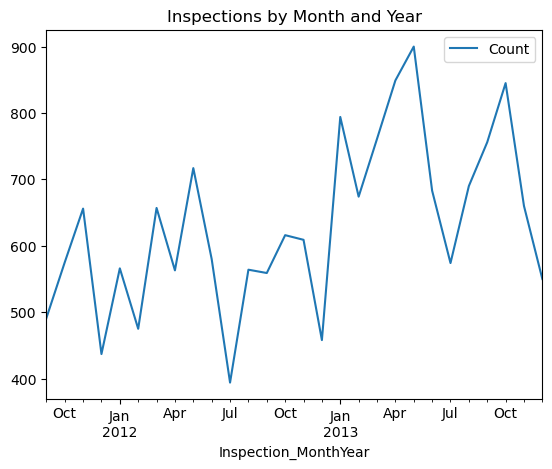

In [27]:
# visualize inspections over time
# -----------
import matplotlib.pyplot as plt

chicago_inspections_2011_to_2013['Inspection_MonthYear'] = chicago_inspections_2011_to_2013['Inspection_Date'].dt.to_period('M')
counts_by_day = chicago_inspections_2011_to_2013.groupby('Inspection_MonthYear').count().rename(columns = {'Facility_Type': 'Count'})['Count'].reset_index()
counts_by_day.set_index(["Inspection_MonthYear"], inplace = True)

ax = counts_by_day.plot(title = "Inspections by Month and Year")
plt.show() 

Let's visualize what the distribution of results looks like.

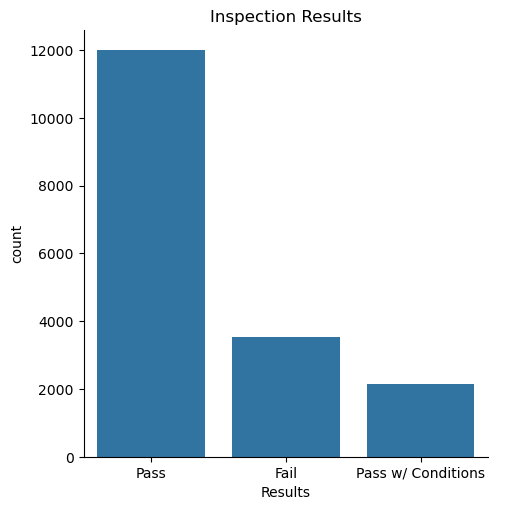

In [28]:
# view inspection results
# -----------
sns.catplot(data = chicago_inspections_2011_to_2013,
           x = "Results",
           kind = "count")

plt.title("Inspection Results")
plt.show()

What if we separate results by facility type?

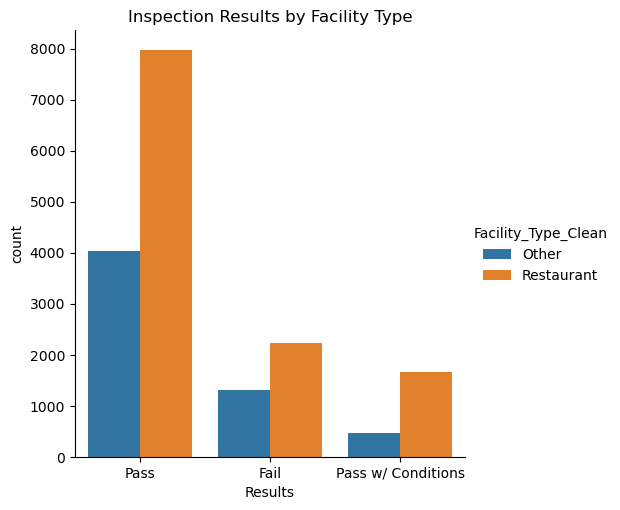

In [29]:
# view inspection results by facility type (restaurant or not)
# -----------
sns.catplot(data = chicago_inspections_2011_to_2013,
            x = "Results",
            kind = "count",
            hue = 'Facility_Type_Clean')

plt.title("Inspection Results by Facility Type")
plt.show();

## 2. Data Preprocessing and Cleaning

In [30]:
# drop datetime info
# -----------
chicago_inspections_2011_to_2013 = chicago_inspections_2011_to_2013.dropna().drop(['Inspection_Date',
                                                                                   'minDate',
                                                                                   'maxDate',
                                                                                   'Inspection_MonthYear'],
                                                                                  axis = 1)

In [31]:
# process target 
# -----------
y = chicago_inspections_2011_to_2013['Results']

# decide if you want to binarize the outcome variable 
# -----------
# comment out the following lines of code if you don't want to binarize the target variable
y = y.replace({'Pass w/ Conditions': 'Pass'})
lb_style = LabelBinarizer()
y = lb_style.fit_transform(y)

# recode 0s and 1s so 1s are "Fail"
y = np.where(y == 1, 0 ,1)


# process features
# -----------

# create feature dataset
X = chicago_inspections_2011_to_2013.drop(columns = ['Results', 
                                                     'Facility_Type', 
                                                     'LICENSE_DESCRIPTION', 
                                                     'WARD_PRECINCT'])


# get dummies
X = pd.get_dummies(X)

In [32]:
# view feature datset
X.head()

,,criticalCount,seriousCount,minorCount,pastFail,pastCritical,pastSerious,pastMinor,timeSinceLast,firstRecord,POLICE_DISTRICT,ageAtInspection,consumption_on_premises_incidental_activity,tobacco,package_goods,outdoor_patio,public_place_of_amusement,limited_business_license,childrens_services_facility_license,tavern,regulated_business_license,filling_station,caterers_liquor_license,mobile_food_license,precipIntensity,temperatureMax,windSpeed,humidity,heat_burglary,heat_garbage,heat_sanitation,criticalFound,Risk_Risk 1 (High),Risk_Risk 2 (Medium),Risk_Risk 3 (Low),Inspection_Type_Canvass,Facility_Type_Clean_Other,Facility_Type_Clean_Restaurant,APPLICATION_TYPE_C_EXPA,APPLICATION_TYPE_C_LOC,APPLICATION_TYPE_ISSUE,APPLICATION_TYPE_RENEW
Inspection_ID,DBA_Name,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
269961,SEVEN STAR,0,0,2,0,0,0,0,2.0,1,19.0,10.964384,0,1,0,0,0,1,0,0,0,0,0,0,0.014587,53.496667,13.340000,0.900000,26.992376,12.768572,37.748787,0,False,False,True,True,True,False,False,False,False,True
507211,PANERA BREAD,0,0,3,0,0,0,0,2.0,1,24.0,7.457534,0,0,0,0,0,0,0,0,0,0,0,0,0.001907,59.046667,13.016667,0.550000,13.976557,12.895485,15.412267,0,True,False,False,True,False,True,False,False,False,True
507212,LITTLE QUIAPO RESTAURANT,0,2,6,0,0,0,0,2.0,1,17.0,4.578082,0,0,0,0,0,0,0,0,0,0,0,0,0.001907,59.046667,13.016667,0.550000,12.611239,8.004220,8.320330,0,True,False,False,True,False,True,False,False,False,True
507216,SERGIO'S TAQUERIA PIZZA INC.,0,0,6,0,0,0,0,2.0,1,17.0,7.805479,0,0,0,0,0,0,0,0,0,0,0,0,0.002737,56.153333,10.863333,0.616667,35.906383,26.238645,38.186618,0,True,False,False,True,False,True,False,False,False,True
507219,TARGET STORE # T-2079,0,2,6,0,0,0,0,2.0,1,24.0,5.290411,0,0,1,0,0,1,0,0,0,0,0,0,0.009987,52.730000,16.266667,0.690000,9.530785,3.401567,2.126788,0,False,True,False,True,False,True,False,False,False,True


## 3. Fit Models

Now choose 3 different machine learning techniques and apply them below. Choose from one of the algorithms we have used in lab (e.g., logistic regression, random forests, `AdaBoost()`, `xgboost()`, `VotingClassifer()`, or `BART`). 

Detail the basic logic and assumptions underlying each model, its pros/cons, and why it is a plausible choice for this problem. Also, be sure to do the following:

1. Import the appropriate library from sklearn
2. Set up a hyperparameter grid (check out our previous labs to see how to do this)
3. Find the best hyperparameters, and then fit your model (using either train/validation splits or cross-validation)

### Model 1- Logistic Regression
#### Basic Idea：
1. Models the log-odds of failure as a linear function of the predictors
2. Assumes additive, linear effects
3. Very transparent and easy to interpret

#### Pros：
1. Highly interpretable（coefficients directly show direction + magnitude）
2. Fast and easy to train
3. Great baseline model for comparison
4. Handles large datasets well

#### Cons
1.Assumes linearity, which is unrealistic for many inspection patterns
2.Cannot naturally capture feature interactions
3.Performance usually weaker than tree-based methods on structured data

#### Personal Takeaway
Logistic regression helped me understand the basic structure of the dataset and which features matter the most. Even though it’s simple, it gave me a good reference point before moving to more flexible models.

In [67]:
from sklearn.model_selection import train_test_split

X_train, X_validate, y_train, y_validate = train_test_split(
    X, 
    y,
    test_size=0.2,
    random_state=42,
    stratify=y 
)

In [68]:
from sklearn.linear_model import LogisticRegression

In [69]:
# create a model
logit_reg = LogisticRegression()

# fit the model
logit_model = logit_reg.fit(X_train, y_train.ravel())

# predict on the validation data
y_pred = logit_model.predict(X_validate)

In [70]:
# extract the coefficents and create a dataframe for plotting 
logit_data = pd.concat([pd.DataFrame(X.columns),
                        pd.DataFrame(np.transpose(logit_model.coef_))],
                       axis = 1)

logit_data.columns = ['Feature', 'Coefficient']
logit_data['abs_coef'] = abs(logit_data['Coefficient'])

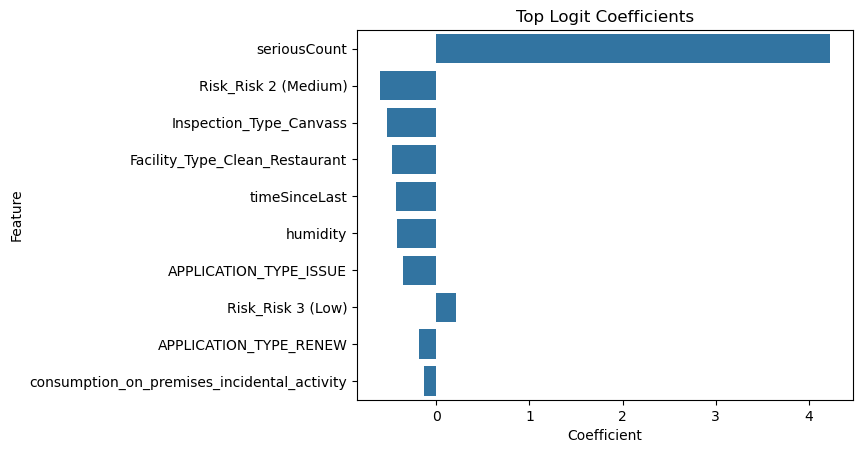

In [71]:
# plot 
sns.barplot(x="Coefficient", 
            y="Feature", 
            data=logit_data.nlargest(10, 'abs_coef')).set_title("Top Logit Coefficients")
plt.show()

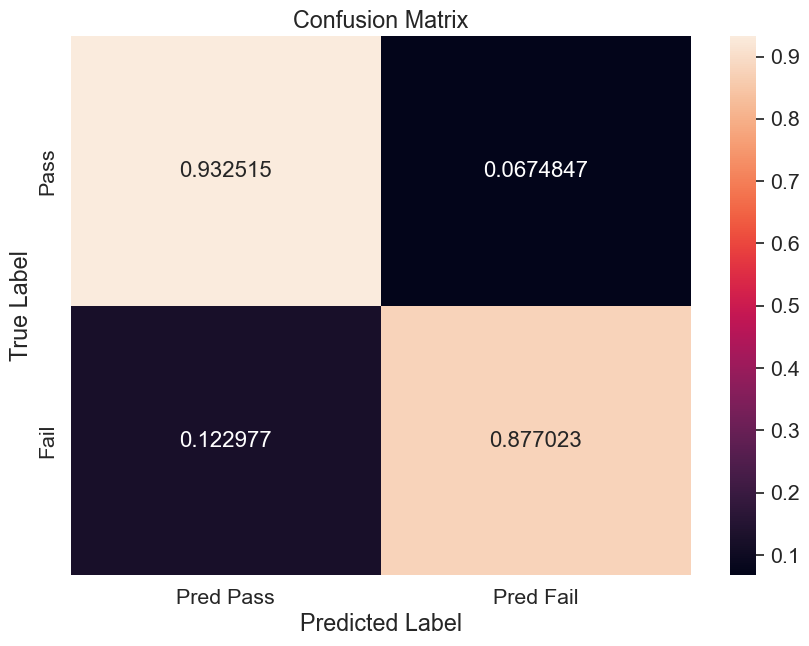

In [74]:
from sklearn.metrics import confusion_matrix

# create a confusion matrix
cf_matrix = confusion_matrix(y_validate, 
                             y_pred, 
                             normalize = "true")

# convert to a dataframe
df_cm = pd.DataFrame(cf_matrix, range(2), range(2))

# set figure specifications
df_cm = df_cm.rename(index=str, columns={0: "Pred Pass", 1: "Pred Fail"})
df_cm.index = ["Pass", "Fail"]
plt.figure(figsize = (10,7))
sns.set(font_scale=1.4)#for label size
sns.heatmap(df_cm, 
           annot=True,
           annot_kws={"size": 16},
           fmt='g')

# plot
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

###  Model 2 -- XGBoost

#### Basic Idea：
1. Gradient boosting of decision trees
2. Learns nonlinear relationships and interactions
3. Very powerful for structured/tabular datasets

#### Pros：
1. Top performance on tabular data
2. Captures nonlinearities + interactions automatically
3. Provides feature importance
4. Handles missingness and variable types robustly

#### Cons:
1. Less interpretable than linear models
2. Many hyperparameters → risk of overfitting if not tuned properly
3. Feature importance doesn’t indicate the direction of effects

#### Personal Takeaway
XGBoost delivered strong predictive performance and revealed consistent feature importance patterns. It complements logistic regression well by uncovering nonlinear patterns LR cannot capture.

In [41]:
!pip install xgboost
import xgboost as xgb

  Using cached xgboost-3.1.2-py3-none-macosx_12_0_arm64.whl.metadata (2.1 kB)
Using cached xgboost-3.1.2-py3-none-macosx_12_0_arm64.whl (2.2 MB)


In [42]:
from sklearn.metrics import (
    make_scorer,
    accuracy_score,
    recall_score,
    precision_score,
    f1_score
)
from sklearn.model_selection import cross_validate


In [43]:
# initialize an XGBoost classifier
# ----------
xgb_classifier = xgb.XGBClassifier(random_state=10)


# define the scoring metrics
scoring = {
          'accuracy': make_scorer(accuracy_score),
          'recall': make_scorer(recall_score),
          'precision': make_scorer(precision_score),
          'f1': make_scorer(f1_score)
          }


# perform cross-validation with 5-fold and return the trained estimators
cv_results = cross_validate(xgb_classifier,        # specify estimator 
                            X,                     # specify features
                            y.ravel(),             # specify outcome, and use ravel
                            cv=5,                  # specify 5-fold cross validation
                            return_estimator=True, # return the estimators fitted at each split
                            scoring=scoring)       # which scoring metrics to return (the whole list in this case)
 
# print the results for accuracy, recall, precision, and F1 score
for metric in ['test_accuracy', 'test_recall', 'test_precision', 'test_f1']:
    scores = cv_results[metric]
    print(f"{metric[5:]}: {scores.mean():.3f}")

accuracy: 0.919
recall: 0.839
precision: 0.779
f1: 0.807


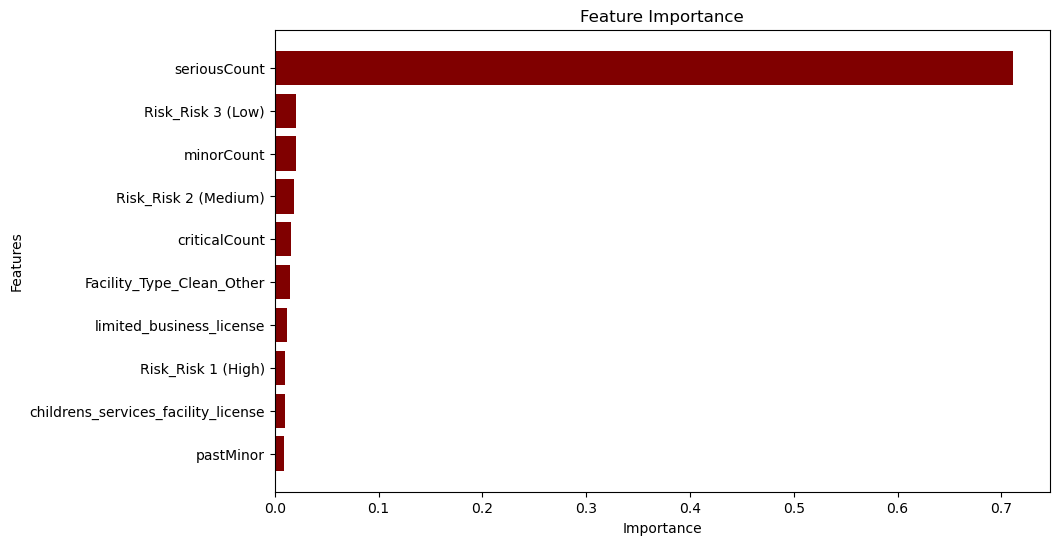

In [44]:
# Let's look at the feature importance
# ----------

# Initialize an array to hold the feature importances
importances = np.zeros(X.shape[1])

# Average the feature importances over the folds
for estimator in cv_results['estimator']:
    importances += estimator.feature_importances_
    
# Divide by the number of folds
importances /= 5  

# Create a DataFrame for visualization
feature_importance = pd.DataFrame({'feature': X.columns, 
                                   'importance': importances})

# Sort the features by importance
feature_importance = feature_importance.sort_values('importance', ascending=False)

# Take the top 10 features
feature_importance = feature_importance.head(10)

# Plot the feature importances
plt.figure(figsize=(10, 6))

# horizontal bar plot
plt.barh(feature_importance['feature'], 
         feature_importance['importance'], 
         color='maroon', 
         align='center')

# labels
plt.xlabel('Importance')
plt.ylabel('Features')
plt.title('Feature Importance')

# gca stands for "get current axis", which allows you to modify the properties of the axes.
# and then inverts the y-axis, meaning that the values that were at the bottom will now be at the top, and vice versa.
plt.gca().invert_yaxis() 
plt.show()

### Model 3 BART

#### Basic Idea
1. Sum of many small regression trees, estimated under a Bayesian framework
2. Produces full posterior distributions instead of point predictions
3. Good at modeling complex interactions

#### Pros
1. Naturally captures nonlinear effects like boosted trees
2. Provides uncertainty estimates—useful for risk-based audit prioritization
3. Allows partial dependence–style visualizations using posterior draws

#### Cons
1. Much slower than LR/XGBoost
2. Harder to tune (number of trees, priors, MCMC sampling)
3. Interpretability relies on post-hoc plots, not direct coefficients

#### Personal Takeaway:
BART allowed me to examine both uncertainty and the detailed shape of feature effects, which adds nuance far beyond point estimates. Fitting the model was much more computationally intensive—I spent more time running and tuning it compared to the other models. However, the posterior-based interpretability, especially the smooth partial dependence–style effects and uncertainty intervals, provided insights that neither logistic regression nor XGBoost could offer.

In [75]:
!pip install pymc
!pip install pymc_bart

In [76]:
import numpy as np
import pymc as pm
import pymc_bart as pmb
import arviz as az

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score

RANDOM_SEED = 123
rng = np.random.default_rng(RANDOM_SEED)

In [77]:
X_np = X.values.astype("float32")      # features
y_np = y.ravel().astype("int16")       # 0 = Pass, 1 = Fail

X_train, X_valid, y_train, y_valid = train_test_split(
    X_np,
    y_np,
    test_size=0.2,
    random_state=RANDOM_SEED,
    stratify=y_np,
)

print("Original shapes:", X_np.shape, y_np.shape)
print("After split:")
print("X_train:", X_train.shape, "X_valid:", X_valid.shape)
print("y_train:", y_train.shape, "y_valid:", y_valid.shape)

Original shapes: (15311, 41) (15311,)
After split:
X_train: (12248, 41) X_valid: (3063, 41)
y_train: (12248,) y_valid: (3063,)


In [78]:
with pm.Model() as bart_model:
    X_data = pm.Data("X_data", X_train)

    # 1. BART prior on the log-odds μ(X)
    mu = pmb.BART(
        "mu",
        X=X_data,
        Y=y_train,
        m=50,                 # number of trees
    )

    # 2. Convert log-odds to probability of FAIL
    p_fail = pm.Deterministic("p_fail", pm.math.sigmoid(mu))

    # 3. Bernoulli likelihood for observed labels
    y_obs = pm.Bernoulli("y_obs", p=p_fail, observed=y_train)

    # 4. MCMC sampling
    idata_bart = pm.sample(
        draws=500,
        tune=500,
        chains=2,
        random_seed=RANDOM_SEED,
        progressbar=True,
    )


Multiprocess sampling (2 chains in 2 jobs)
PGBART: [mu]


Output()

Sampling 2 chains for 500 tune and 500 draw iterations (1_000 + 1_000 draws total) took 60 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


In [79]:
def bart_predict_proba(model, idata, X_new, seed=RANDOM_SEED):
    with model:
        pm.set_data({"X_data": X_new})
        ppc = pm.sample_posterior_predictive(
            idata,
            var_names=["p_fail"],
            random_seed=seed,
        )
    # p_fail has dims (chain, draw, obs_id)
    p_fail_samples = ppc.posterior_predictive["p_fail"]
    probs = p_fail_samples.mean(dim=("chain", "draw")).values
    return probs

In [80]:
probs_train = bart_predict_proba(bart_model, idata_bart, X_train)
y_pred_train = (probs_train > 0.5).astype(int)

bart_acc_train = accuracy_score(y_train, y_pred_train)
bart_rec_train = recall_score(y_train, y_pred_train)
bart_prec_train = precision_score(y_train, y_pred_train)
bart_f1_train = f1_score(y_train, y_pred_train)

print("=== BART on TRAIN ===")
print(f"Accuracy  : {bart_acc_train:.3f}")
print(f"Recall    : {bart_rec_train:.3f}")
print(f"Precision : {bart_prec_train:.3f}")
print(f"F1 score  : {bart_f1_train:.3f}")


Sampling: []


Output()

=== BART on TRAIN ===
Accuracy  : 0.917
Recall    : 0.887
Precision : 0.747
F1 score  : 0.811


In [81]:
probs_valid = bart_predict_proba(bart_model, idata_bart, X_valid)
y_pred_valid = (probs_valid > 0.5).astype(int)

bart_acc_valid = accuracy_score(y_valid, y_pred_valid)
bart_rec_valid = recall_score(y_valid, y_pred_valid)
bart_prec_valid = precision_score(y_valid, y_pred_valid)
bart_f1_valid = f1_score(y_valid, y_pred_valid)

print("\n=== BART on VALID ===")
print(f"Accuracy  : {bart_acc_valid:.3f}")
print(f"Recall    : {bart_rec_valid:.3f}")
print(f"Precision : {bart_prec_valid:.3f}")
print(f"F1 score  : {bart_f1_valid:.3f}")

Sampling: [mu]


Output()


=== BART on VALID ===
Accuracy  : 0.924
Recall    : 0.948
Precision : 0.744
F1 score  : 0.834


/var/folders/f0/mcczjw3s06d9d_9sn42lsd400000gn/T/ipykernel_42426/593194422.py:28: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  agg = df_plot.groupby("bin")["prob"].agg(["mean", "std"])
/var/folders/f0/mcczjw3s06d9d_9sn42lsd400000gn/T/ipykernel_42426/593194422.py:29: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bin_centers = df_plot.groupby("bin")["feature"].apply(lambda x: x.mean()).values


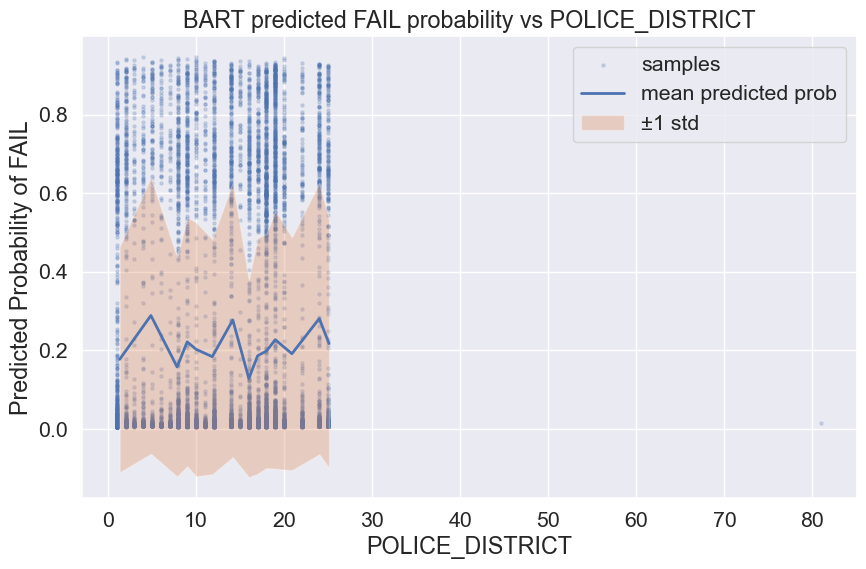

In [82]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

feature_name = "POLICE_DISTRICT"            
feature_idx = list(X.columns).index(feature_name)

x_feature = X_train[:, feature_idx]
probs = probs_train  

plt.figure(figsize=(10, 6))

plt.scatter(
    x_feature,
    probs,
    s=5,
    alpha=0.2,
    label="samples"
)

df_plot = pd.DataFrame({
    "feature": x_feature,
    "prob": probs
})

df_plot["bin"] = pd.qcut(df_plot["feature"], q=20, duplicates="drop")

agg = df_plot.groupby("bin")["prob"].agg(["mean", "std"])
bin_centers = df_plot.groupby("bin")["feature"].apply(lambda x: x.mean()).values
mean_probs = agg["mean"].values
std_probs = agg["std"].values

plt.plot(bin_centers, mean_probs, lw=2, label="mean predicted prob")
plt.fill_between(
    bin_centers,
    mean_probs - std_probs,
    mean_probs + std_probs,
    alpha=0.3,
    label="±1 std"
)

plt.xlabel(feature_name)
plt.ylabel("Predicted Probability of FAIL")
plt.title(f"BART predicted FAIL probability vs {feature_name}")
plt.legend()
plt.show()


### Validation Metrics

Be sure to explain which of these metrics you would want to prioritize when conducting predictive auditing in this context and why.

**Hint**: Try writing a for loop to use [`cross_val_score()`](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.cross_val_score.html) to check for accuracy, precision, recall and f1 across all of your models.

In [83]:
from sklearn.model_selection import cross_val_score
import pandas as pd

# make sure y is 1D array of 0/1
y_flat = y.ravel()

# sklearn models to compare
models = {
    "Logistic Regression": logit_reg,      
    "XGBoost": xgb_classifier,             
}

# metrics we care about
scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
}

val_results = {}

# ---- 1) cross-validation for LR and XGBoost ----
for model_name, clf in models.items():
    val_results[model_name] = {}
    for metric_name, scoring_name in scoring.items():
        scores = cross_val_score(
            clf,
            X,
            y_flat,
            cv=5,
            scoring=scoring_name,
        )
        val_results[model_name][metric_name] = scores.mean()
        print(f"{model_name} - {metric_name}: {scores.mean():.3f}")

# ---- 2) add BART using its validation-set metrics ----
val_results["BART"] = {
    "accuracy": bart_acc_valid,
    "precision": bart_prec_valid,
    "recall": bart_rec_valid,
    "f1": bart_f1_valid,
}

# ---- 3) summary table ----
val_results_df = pd.DataFrame(val_results).T
val_results_df


The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.
Logistic Regression - accuracy: 0.918
Logistic Regression - precision: 0.769
Logistic Regression - recall: 0.855
Logistic Regression - f1: 0.808
XGBoost - accuracy: 0.919
XGBoost - precision: 0.779
XGBoost - recall: 0.839
XGBoost - f1: 0.807


,accuracy,precision,recall,f1
Logistic Regression,0.918098,0.768852,0.854905,0.807770
XGBoost,0.919274,0.778765,0.839345,0.807389
BART,0.923604,0.743655,0.948220,0.833570


#### Validation Interpretation

The three models all perform reasonably well, but they behave a bit differently:

Logistic Regression is simple and consistent, though it tends to miss more “Fail” cases due to its lower recall.
XGBoost gives a more balanced performance and improves slightly over LR, especially on recall.
BART stands out with the highest recall and strongest F1 score, meaning it catches the most risky inspections—something that matters a lot for audit prioritization.

Overall, even though BART took noticeably more time to run, its ability to detect more failures makes it the most useful model for this task.

## 4. Policy Simulation

### Interpretable Machine Learning

Use tools like coefficient plots or feature importance plots to investigate your models. Which features contribute to your predictions? Are there any additional features you wish you could incorporate that you don't have available in this analysis?

**Hint**: Use tools like feature importance plots and coefficient plots.

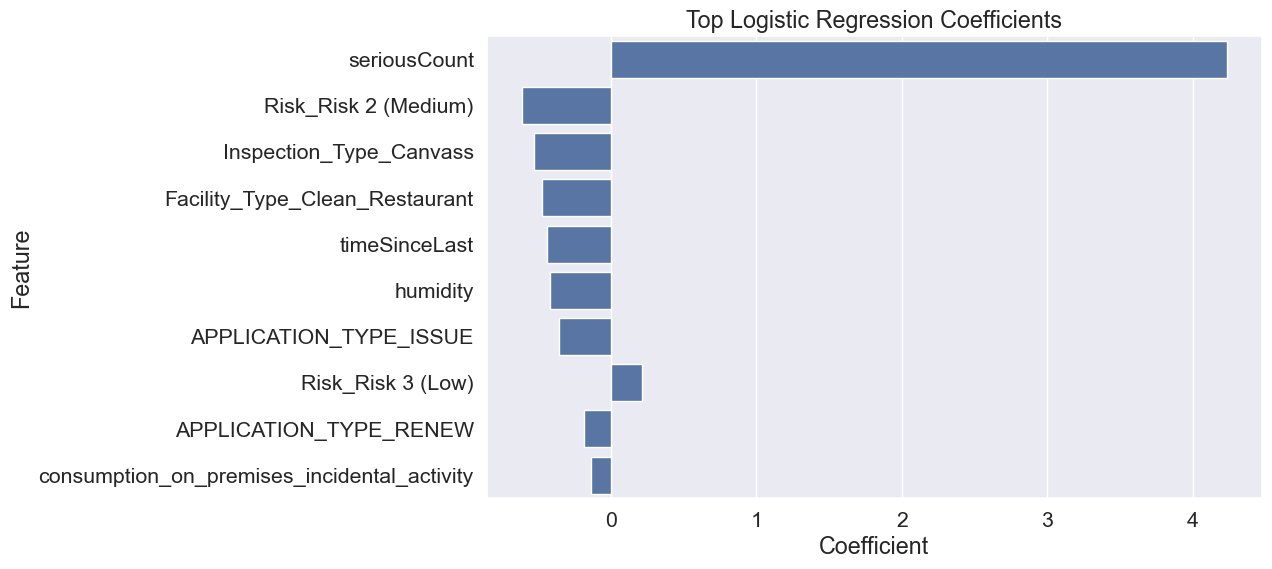

In [84]:
# Extract coefficients for LR
logit_data = pd.concat(
    [pd.DataFrame(X.columns), pd.DataFrame(logit_model.coef_.T)],
    axis=1
)
logit_data.columns = ["Feature", "Coefficient"]
logit_data["abs_coef"] = logit_data["Coefficient"].abs()

# Plot top 10 coefficients by absolute value
plt.figure(figsize=(10, 6))
sns.barplot(
    data=logit_data.nlargest(10, "abs_coef"),
    y="Feature",
    x="Coefficient"
)
plt.title("Top Logistic Regression Coefficients")
plt.show()


#### Logistic Regession Interpretation

From the LR coefficients, the story is pretty straightforward: seriousCount stands out immediately — having even one serious violation pushes the predicted failure risk way up. A few other features like medium risk level and certain inspection types also play noticeable roles, but most variables barely move the needle.

Overall, LR gives a nice “big-picture ranking” of what matters most, even though it simplifies some relationships.




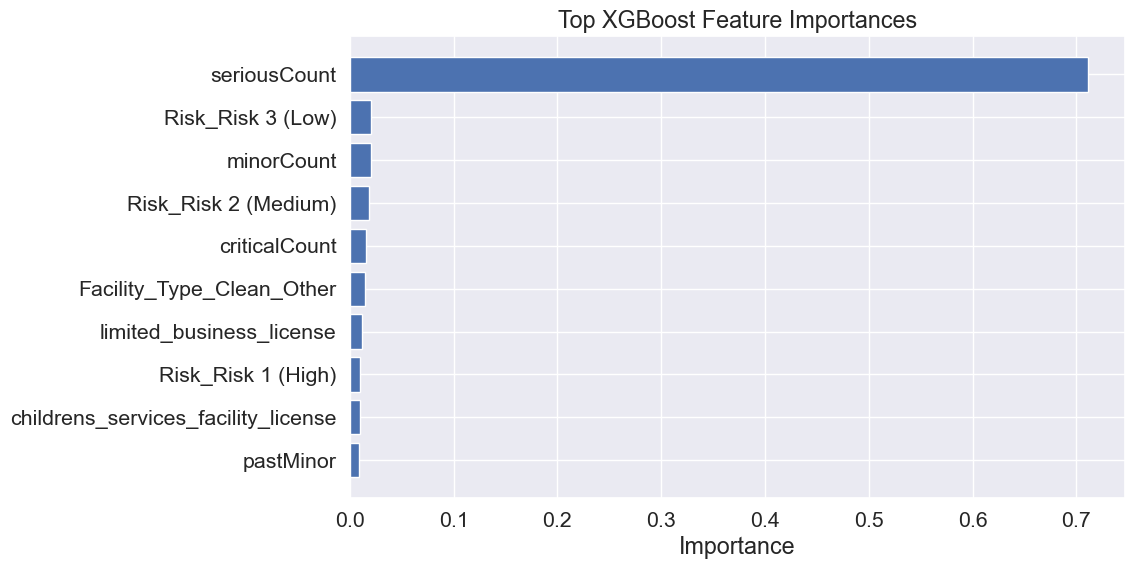

In [85]:
# Retrieve and average feature importances from cross-validation
importances = np.zeros(X.shape[1])
for estimator in cv_results["estimator"]:
    importances += estimator.feature_importances_
importances /= len(cv_results["estimator"])

# Create dataframe
feature_importance = pd.DataFrame({
    "feature": X.columns,
    "importance": importances
}).sort_values("importance", ascending=False)

# Plot top 10
plt.figure(figsize=(10, 6))
plt.barh(feature_importance["feature"].head(10),
         feature_importance["importance"].head(10))
plt.gca().invert_yaxis()
plt.title("Top XGBoost Feature Importances")
plt.xlabel("Importance")
plt.show()

#### XGBoost Interpretation

XGBoost basically reinforces what LR showed, but in a much sharper way. seriousCount again dominates, and everything else drops off quickly. This tells me the model is relying heavily on a small set of truly strong signals.
It also makes sense given the domain—serious violations are simply much more informative than anything else. XGBoost just captures that pattern more flexibly than LR.



Sampling: [μ]


Output()

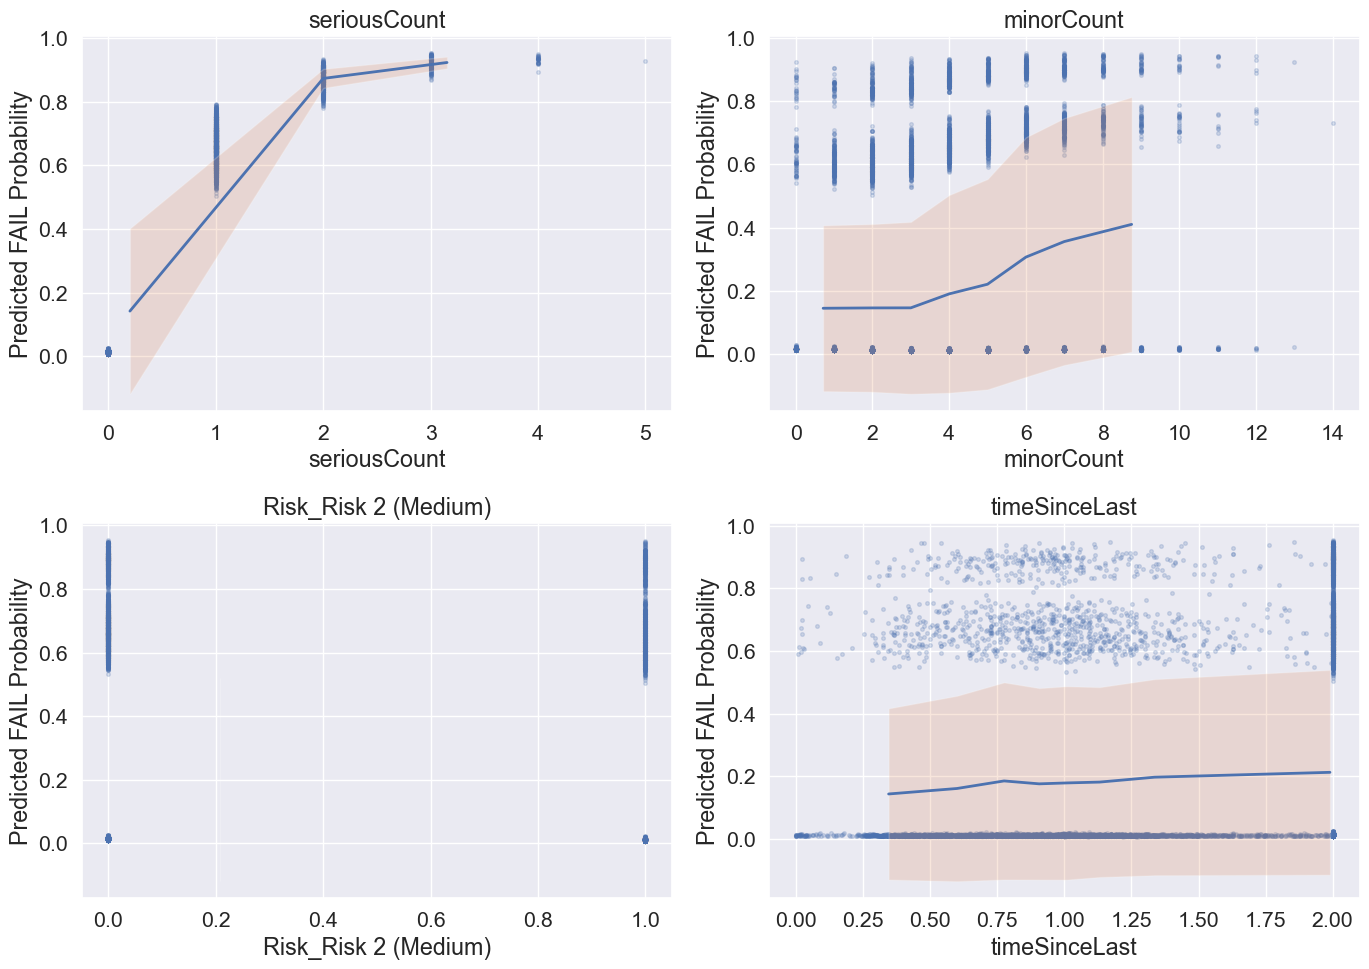

In [99]:
# === posterior mean predicted probability on TRAIN ===
with model_bart_cls:
    pm.set_data({"X_data": X_train})
    ppc_train = pm.sample_posterior_predictive(
        idata_bart,
        var_names=["p_fail"]
    )

probs_train = ppc_train.posterior_predictive["p_fail"]
probs_train_mean = probs_train.mean(dim=("chain", "draw")).values


# === choose 4 features ===
feature_list = [
    "seriousCount",
    "minorCount",
    "Risk_Risk 2 (Medium)",
    "timeSinceLast"
]

feature_idx_list = [list(X_columns).index(f) for f in feature_list]


# === plotting ===
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for ax, f_name, f_idx in zip(axes, feature_list, feature_idx_list):

    x_feature = X_train[:, f_idx]
    probs = probs_train_mean

    # scatter
    ax.scatter(x_feature, probs, s=7, alpha=0.2)

    # binned smoothing
    df_tmp = pd.DataFrame({"feature": x_feature, "prob": probs})
    df_tmp["bin"] = pd.qcut(df_tmp["feature"], q=20, duplicates="drop")

    agg = df_tmp.groupby("bin", observed=False)["prob"].agg(["mean", "std"])
    bin_centers = df_tmp.groupby("bin", observed=False)["feature"].apply(lambda x: x.mean())

    ax.plot(bin_centers, agg["mean"], lw=2)
    ax.fill_between(
        bin_centers,
        agg["mean"] - agg["std"],
        agg["mean"] + agg["std"],
        alpha=0.2
    )

    ax.set_title(f"{f_name}")
    ax.set_xlabel(f_name)
    ax.set_ylabel("Predicted FAIL Probability")

plt.tight_layout()
plt.show()


#### BART Interpretation

For the BART plots, I focused on four features — seriousCount, minorCount, the medium-risk indicator, and timeSinceLast. I selected these mainly because both Logistic Regression and XGBoost consistently ranked them among the most influential predictors, so they seemed worth examining in more depth. BART can handle a much larger feature space, but for interpretability I followed the earlier model results and chose the variables that were both important and substantively meaningful.

From the BART partial-dependence curves:

1. seriousCount remains the strongest driver — moving from 0 to 1–2 violations sharply increases the predicted failure probability.
2. minorCount shows a slower, more gradual effect, with wider uncertainty.
3. Risk 2 (Medium) produces a clear upward shift in predicted failure risk.
4. timeSinceLast shows only a mild upward trend, suggesting a weaker marginal contribution.

Compared with LR and XGBoost, BART’s main benefit is the ability to see non-linear shapes and uncertainty around each effect. It’s computationally heavier, but the uncertainty bands make the relationships much easier to interpret and gave me a better sense of how each feature actually behaves across its range.

### Prioritize Audits

**Hint**: Look up the [`.predict()`](https://www.kite.com/python/docs/sklearn.linear_model.SGDRegressor.predict), [`.predict_proba()`](https://www.kite.com/python/docs/sklearn.linear_model.LogisticRegression.predict_proba), and [`.sample()`](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.sample.html) methods. Then: 
1. Choose one of your models (or train a new simplified model or ensemble!) to predict outcomes and probabilities. 
2. Order your audits by their probability of detecting a "Fail" score
3. Plot your distribution of pass/fail among the first 1,000 observations in the dataset
4. Simulate random audits on the full chicago_2011_to_2013.csv dataset by picking 1,000 observations at random

In [112]:
#
# 1. Choose one of your models (or train a new simplified model or ensemble!) to predict outcomes and probabilities.
# -----------

# Fit XGBoost on the full training set
xgb_classifier.fit(X, y.ravel())

# Predicted probability of FAIL (class = 1)
probs_fail = xgb_classifier.predict_proba(X)[:, 1]

df_scores = pd.DataFrame({
    "prob_fail": probs_fail,
    "true_label": y.ravel()
})
df_scores.head()

,prob_fail,true_label
0,0.000063,0
1,0.000114,0
2,0.862935,1
3,0.000234,0
4,0.945848,1


In [121]:
#
# 2. Order your audits by their probability of detecting a "Fail" score
# -----------
df_scores_sorted = df_scores.sort_values("prob_fail", ascending=False)
df_scores_sorted.head()


,prob_fail,true_label
14654,0.999933,1
7218,0.999925,1
14299,0.999920,1
4562,0.999918,1
11850,0.999898,1


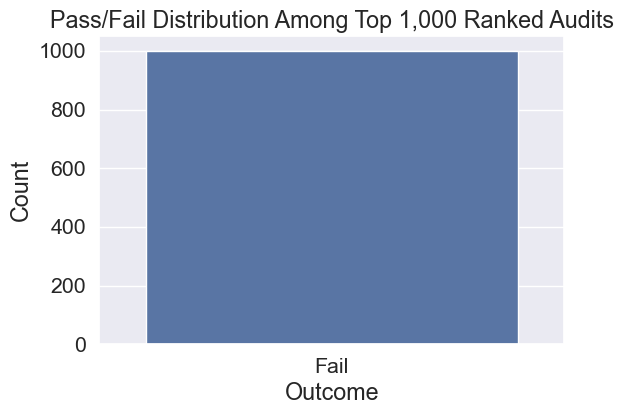

In [123]:
#
# 3. Plot your distribution of pass/fail among the first 1,000 observations in the dataset
# -----------
top1000 = df_scores_sorted.iloc[:1000]

plt.figure(figsize=(6, 4))
sns.countplot(x=top1000["true_label"].replace({0: "Pass", 1: "Fail"}))
plt.title("Pass/Fail Distribution Among Top 1,000 Ranked Audits")
plt.xlabel("Outcome")
plt.ylabel("Count")
plt.show()

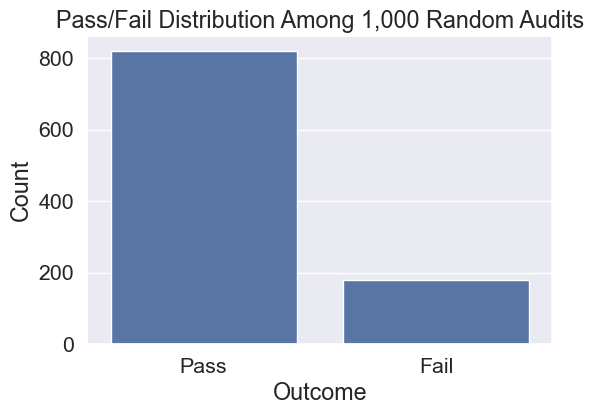

In [124]:
#
# 4. Simulate random audits on the full chicago_2011_to_2013.csv dataset by picking 1,000 observations at random
# -----------
random1000 = df_scores.sample(1000)

plt.figure(figsize=(6, 4))
sns.countplot(x=random1000["true_label"].replace({0: "Pass", 1: "Fail"}))
plt.title("Pass/Fail Distribution Among 1,000 Random Audits")
plt.xlabel("Outcome")
plt.ylabel("Count")
plt.show()

### Predict on 2014 inspection data

Use your favorite model to make predictions based on the features using the "Chicago Inspection 2014_updated.csv" file. Treat this as you would a test dataset. This means you will have to format the features (including removing some features and getting dummies) and the label (binarize and recode) in the same way you did the training data. (Remember the "Results" column is your label). You will then compare your predictions with the actual.

In [125]:
# data processing
# -----------

# process features
X_test2014_raw = chicago_inspections_2014.drop(columns=["Results"])
X_test2014_dummies = pd.get_dummies(X_test2014_raw)
X_test2014 = X_test2014_dummies.reindex(columns=X.columns, fill_value=0)
print("X_test2014 shape:", X_test2014.shape)
# process target 
y_test2014 = (chicago_inspections_2014["Results"] == "Fail").astype(int)
print("y_test2014 shape:", y_test2014.shape)


X_test2014 shape: (4623, 41)
y_test2014 shape: (4623,)


In [126]:
# predict and compare 
# -----------
y_pred_2014 = xgb_classifier.predict(X_test2014)

Accuracy: 0.9043910880380706
Recall: 0.8042269187986651
Precision: 0.731041456016178
F1: 0.7658898305084746


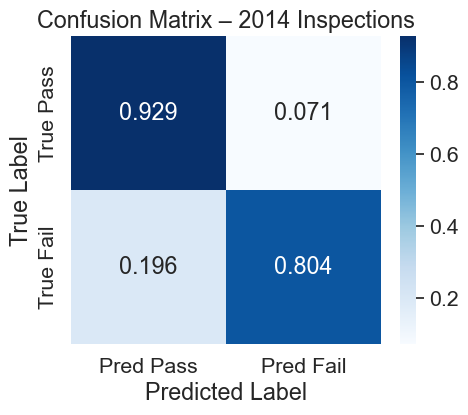

In [128]:
# evaluate
# -----------
print("Accuracy:", accuracy_score(y_test2014, y_pred_2014))
print("Recall:", recall_score(y_test2014, y_pred_2014))
print("Precision:", precision_score(y_test2014, y_pred_2014))
print("F1:", f1_score(y_test2014, y_pred_2014))

cm = confusion_matrix(y_test2014, y_pred_2014, normalize="true")
df_cm = pd.DataFrame(cm,
                     index=["True Pass", "True Fail"],
                     columns=["Pred Pass", "Pred Fail"])

plt.figure(figsize=(5, 4))
sns.heatmap(df_cm, annot=True, fmt=".3f", cmap="Blues")
plt.title("Confusion Matrix – 2014 Inspections")
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.show()

## 5. Discussion Questions

1. Why do we need metrics beyond accuracy when using machine learning in the social sciences and public policy?


Accuracy alone is too limited for real-world policy problems.
Machine learning already simplifies a complex social system, so relying on a single number can hide important risks. For example, when     classes are imbalanced, a model can achieve high accuracy while failing to catch the very cases policymakers care about. Different         errors also have different social costs — missing a risky establishment (a false negative) is far more harmful than flagging a safe one.

Metrics like precision and recall help break down the model’s performance into specific steps of the decision process, showing whether     the model is missing too many risky cases or raising too many false alarms.They also give a more transparent view of model behavior,       improve interpretability, and help policymakers understand whether a model is reliable enough to act on. In short, accuracy is useful,     but it’s too “thin” on its own to support responsible decision-making.

2. Imagine that establishments learned about the algorithm being used to determine who gets audited and they started adjusting their behavior (and changing certain key features about themselves that were important for the prediction) to avoid detection. How could policymakers address this interplay between algorithmic decisionmaking and real world behavior?

If establishments begin adjusting their behavior to avoid being flagged by the algorithm, policymakers need to think carefully about how much and when to disclose information about the system. Some level of transparency is important for accountability, but releasing the full model—or updating businesses right before inspections—would make the algorithm too easy to game. A better approach is to disclose the general logic and goals of the system while keeping the exact thresholds, weights, and timing confidential.

Maintaining a degree of randomness in inspections is also essential. Even if high-risk establishments are prioritized, lower-risk ones should still be sampled periodically so the system does not become fully predictable. This reduces strategic manipulation and ensures fairness across different types of establishments.

Finally, continuous model updates are crucial. If businesses change their behavior in response to the algorithm, the model needs to incorporate those shifts rather than becoming outdated. Regular retraining, monitoring, and iterative improvement allow the algorithm to adapt to new patterns and maintain its effectiveness over time.